In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# For better visualization style
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [2]:
df = pd.read_csv("SUSY.csv")
df.head()

,SUSY,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi,MET_rel,axial MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos(theta_r1)
0,0.0,0.707258,0.613159,-0.763354,1.010814,1.672101,1.544314,0.342641,0.286944,0.514347,-0.008000,0.832800,0.646217,0.688581,1.159059,0.807485,0.890080,0.272718,0.014631
1,0.0,0.493745,-1.745581,-0.640968,0.576161,-0.514477,-0.629788,0.585841,0.874038,0.879419,-0.221701,0.553944,0.770422,1.234180,1.671171,0.511589,1.255531,0.521592,0.158222
2,1.0,1.305413,0.283820,-1.149154,0.507217,-0.194161,1.313993,0.659832,0.619593,0.534922,-0.320298,0.861971,1.085602,1.117620,1.199941,0.754778,0.984459,0.235892,0.601631
3,1.0,0.809715,-0.358303,-0.497172,0.787675,0.027419,1.201305,0.790556,-0.861923,0.740287,0.890525,0.684771,0.717640,0.929989,0.341225,0.683829,0.492741,1.283829,0.115851
4,0.0,0.912852,1.797455,-1.360165,0.496723,1.199644,0.627462,1.206452,-1.362983,0.033791,1.509121,0.659545,0.652570,0.878010,0.000000,0.580894,0.143379,1.438492,0.230821


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000000 entries, 0 to 4999999
Data columns (total 19 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   SUSY                      float64
 1   lepton 1 pT               float64
 2   lepton 1 eta              float64
 3   lepton 1 phi              float64
 4   lepton 2 pT               float64
 5   lepton 2 eta              float64
 6   lepton 2 phi              float64
 7   missing energy magnitude  float64
 8   missing energy phi        float64
 9   MET_rel                   float64
 10  axial MET                 float64
 11  M_R                       float64
 12  M_TR_2                    float64
 13  R                         float64
 14  MT2                       float64
 15  S_R                       float64
 16  M_Delta_R                 float64
 17  dPhi_r_b                  float64
 18  cos(theta_r1)             float64
dtypes: float64(19)
memory usage: 724.8 MB


In [4]:
for col in df.columns:
    print(col, df[col].shape)

SUSY (5000000,)
lepton 1 pT (5000000,)
lepton 1 eta (5000000,)
lepton 1 phi (5000000,)
lepton 2 pT (5000000,)
lepton 2 eta (5000000,)
lepton 2 phi (5000000,)
missing energy magnitude (5000000,)
missing energy phi (5000000,)
MET_rel (5000000,)
axial MET (5000000,)
M_R (5000000,)
M_TR_2 (5000000,)
R (5000000,)
MT2 (5000000,)
S_R (5000000,)
M_Delta_R (5000000,)
dPhi_r_b (5000000,)
cos(theta_r1) (5000000,)


In [5]:
df.describe()

,SUSY,lepton 1 pT,lepton 1 eta,lepton 1 phi,lepton 2 pT,lepton 2 eta,lepton 2 phi,missing energy magnitude,missing energy phi,MET_rel,axial MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos(theta_r1)
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,4.575654e-01,1.000318e+00,2.192580e-05,-4.994657e-05,9.994304e-01,-3.713140e-05,-1.972243e-05,9.999744e-01,3.542352e-05,1.001437e+00,-4.878472e-05,1.000360e+00,9.999559e-01,9.999164e-01,1.000422e+00,1.000112e+00,1.000192e+00,9.994852e-01,2.249139e-01
std,4.981961e-01,6.873341e-01,1.003107e+00,1.001670e+00,6.542200e-01,1.002839e+00,1.001631e+00,8.728877e-01,1.001654e+00,8.901668e-01,1.001594e+00,6.288446e-01,5.841139e-01,4.708406e-01,8.592491e-01,6.207165e-01,6.237672e-01,4.360948e-01,1.969804e-01
min,0.000000e+00,2.548815e-01,-2.102927e+00,-1.734789e+00,4.285860e-01,-2.059306e+00,-1.734202e+00,2.598711e-04,-1.727117e+00,7.693475e-08,-1.671863e+01,2.673070e-01,1.041228e-03,2.048078e-03,0.000000e+00,2.734135e-02,4.452858e-03,3.211849e-07,4.172130e-08
25%,0.000000e+00,5.624837e-01,-7.573512e-01,-8.673567e-01,5.969881e-01,-7.695916e-01,-8.683741e-01,4.784546e-01,-8.661510e-01,3.691849e-01,-4.923983e-01,5.883287e-01,6.223411e-01,6.505438e-01,1.705215e-01,5.985209e-01,5.134394e-01,6.879128e-01,6.908188e-02
50%,0.000000e+00,7.915511e-01,1.342127e-04,-3.880155e-04,7.997993e-01,-3.793710e-04,2.006134e-04,7.738360e-01,-9.172642e-03,8.019273e-01,-8.037898e-02,8.286114e-01,8.781311e-01,9.344703e-01,9.018388e-01,8.355336e-01,9.142514e-01,1.094396e+00,1.672500e-01
75%,1.000000e+00,1.204413e+00,7.576486e-01,8.670981e-01,1.162353e+00,7.692296e-01,8.674778e-01,1.207444e+00,8.687620e-01,1.375392e+00,3.489009e-01,1.211083e+00,1.220313e+00,1.283522e+00,1.613231e+00,1.207994e+00,1.384583e+00,1.369183e+00,3.303652e-01
max,1.000000e+00,2.055345e+01,2.101605e+00,1.734839e+00,3.303562e+01,2.059721e+00,1.734686e+00,2.106888e+01,1.740689e+00,2.338644e+01,2.048790e+01,2.107572e+01,1.616682e+01,6.731210e+00,2.068624e+01,2.115226e+01,1.561370e+01,1.591660e+00,1.000000e+00


In [6]:
# 3. Class Distribution
class_counts = df["SUSY"].value_counts()
print("\nClass distribution:")
print(class_counts)


Class distribution:
SUSY
0.0    2712173
1.0    2287827
Name: count, dtype: int64


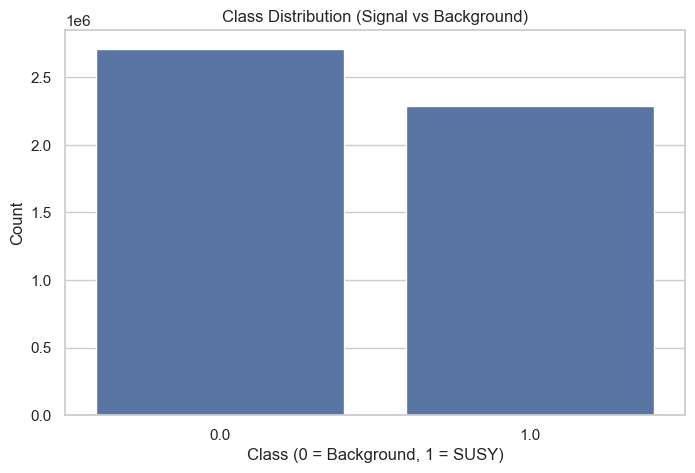

In [7]:
plt.figure()
sns.countplot(x="SUSY", data=df)
plt.title("Class Distribution (Signal vs Background)")
plt.xlabel("Class (0 = Background, 1 = SUSY)")
plt.ylabel("Count")
plt.show()

In [8]:
#Feature Distributions by Class

# Separate signal and background
signal = df[df["SUSY"] == 1]
background = df[df["SUSY"] == 0]

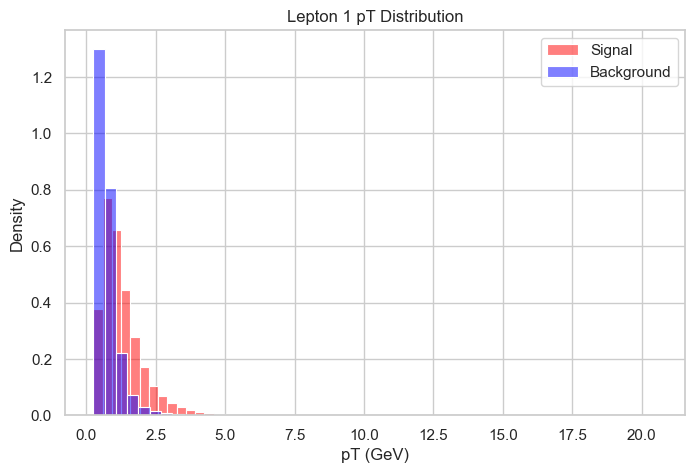

In [9]:
# Example: Lepton 1 pT
plt.figure()
sns.histplot(signal["lepton 1 pT"], color="red", label="Signal",
             stat="density", bins=50, alpha=0.5)
sns.histplot(background["lepton 1 pT"], color="blue", label="Background",
             stat="density", bins=50, alpha=0.5)

plt.legend()
plt.title("Lepton 1 pT Distribution")
plt.xlabel("pT (GeV)")
plt.ylabel("Density")
plt.show()

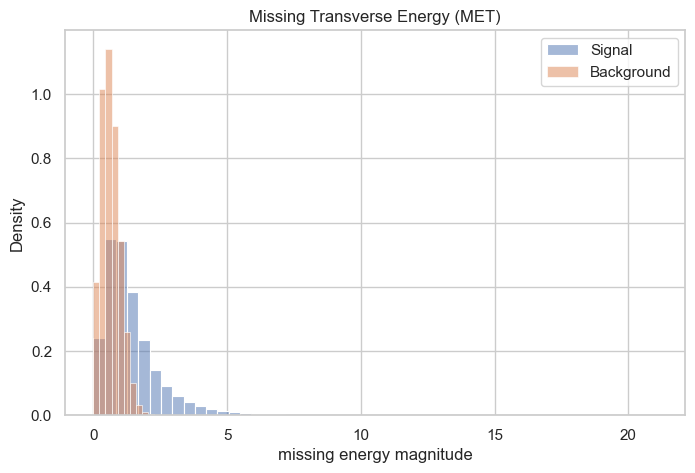

In [10]:
#Missing Energy Analysis
plt.figure()
sns.histplot(signal["missing energy magnitude"], 
             bins=50, stat="density", alpha=0.5, label="Signal")
sns.histplot(background["missing energy magnitude"], 
             bins=50, stat="density", alpha=0.5, label="Background")

plt.legend()
plt.title("Missing Transverse Energy (MET)")
plt.show()

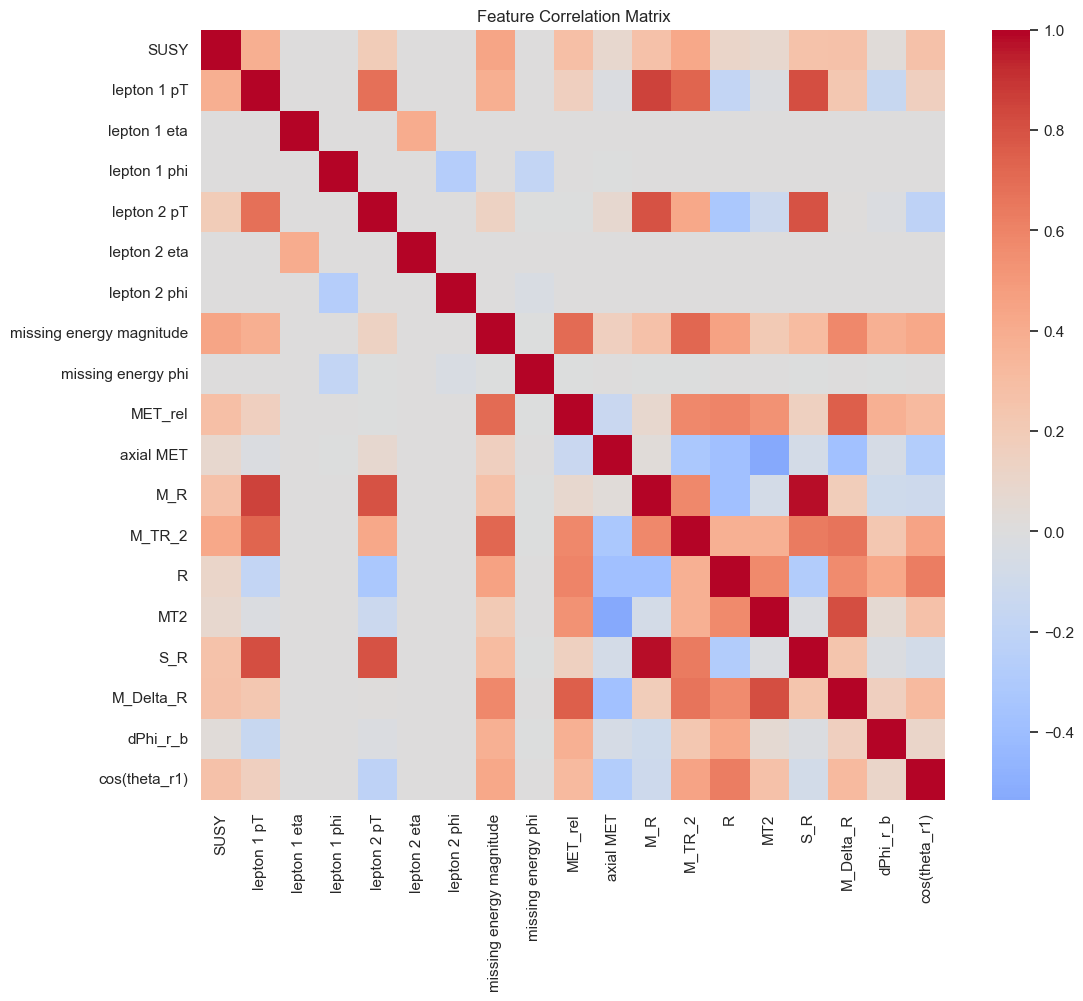

In [11]:
#Correlation Matrix
plt.figure(figsize=(12, 10))
corr_matrix = df.corr()

sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix")
plt.show()

In [12]:
mean_signal = signal.mean()
mean_background = background.mean()

In [13]:
separation = (mean_signal - mean_background) / df.std()

separation = separation.sort_values(ascending=False)

In [ ]:
print("\nTop features by separation power:")
print(separation.head(10))


Top features by separation power:
SUSY                        2.007242
missing energy magnitude    0.880820
M_TR_2                      0.849124
lepton 1 pT                 0.777600
MET_rel                     0.567603
M_Delta_R                   0.547961
cos(theta_r1)               0.539507
M_R                         0.535109
S_R                         0.518522
lepton 2 pT                 0.391000
dtype: float64


In [15]:
#Pairplot of Important Features
important_features = separation.head(4).index.tolist()

In [16]:
print(important_features)

['SUSY', 'missing energy magnitude', 'M_TR_2', 'lepton 1 pT']


In [17]:
for col in important_features:
    print(col, df[col].shape)

SUSY (5000000,)
missing energy magnitude (5000000,)
M_TR_2 (5000000,)
lepton 1 pT (5000000,)


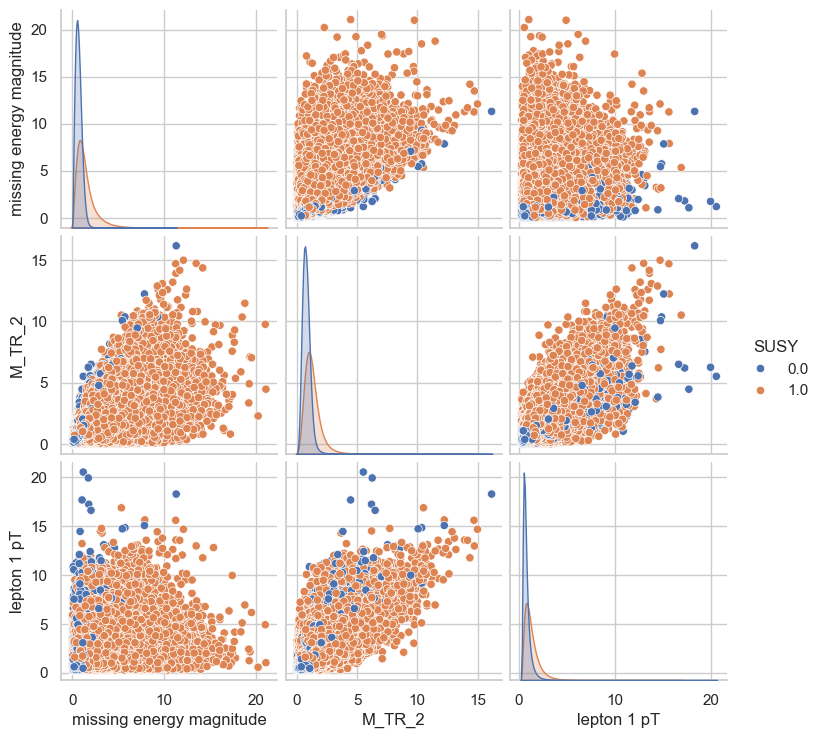

In [45]:
sns.pairplot(df[important_features], 
             hue="SUSY", diag_kind="kde")
plt.show()

In [ ]:
#We will build a simple logistic regression model as a baseline, and then we will try a more complex model like XGBoost to see if we can improve the performance.

In [ ]:
#Now we will prepare the data for modeling. We will split the data into features (X) and target (y), and then perform a train-test split.

In [18]:
# Separate features and label
X = df.drop("SUSY", axis=1)
y = df["SUSY"]

print("Dataset shape:", df.shape)

Dataset shape: (5000000, 19)


In [19]:
# Prepare data for modeling by separating features and target
# Stratified split preserves signal/background ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 4000000
Testing samples: 1000000


In [ ]:
# Standard Scaling because logistic regression and XGBoost are ensitive to feature scales.
scaler = StandardScaler()

# Fit only on training data to avoid data leakage
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using same parameters
X_test_scaled = scaler.transform(X_test)

In [21]:
# Logistic Regression is the baseline model for classification tasks, and it is a good starting point to evaluate the performance before trying more complex models.

log_model = LogisticRegression(
    max_iter=1000,
    n_jobs=-1
)

log_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
# Predict probabilities
y_pred_proba_log = log_model.predict_proba(X_test_scaled)[:, 1]

In [23]:
# AUC score
auc_log = roc_auc_score(y_test, y_pred_proba_log)
print("Logistic Regression AUC:", auc_log)

Logistic Regression AUC: 0.8576992644208142


In [24]:
# Classification report
print(classification_report(y_test, log_model.predict(X_test_scaled)))

              precision    recall  f1-score   support

         0.0       0.76      0.88      0.82    542435
         1.0       0.83      0.68      0.75    457565

    accuracy                           0.79   1000000
   macro avg       0.80      0.78      0.78   1000000
weighted avg       0.79      0.79      0.79   1000000



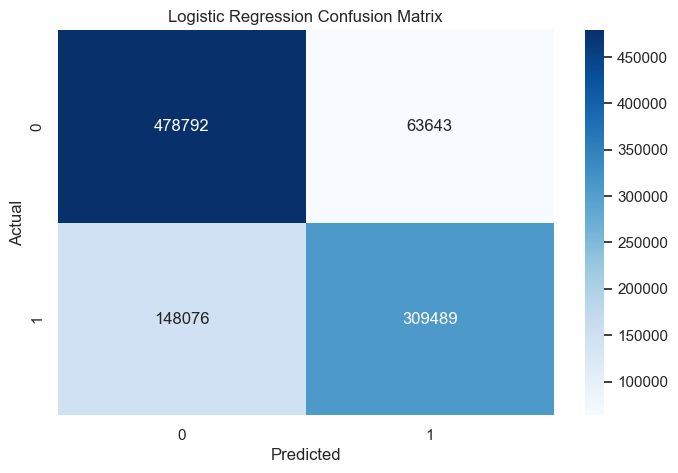

In [25]:
# Confusion Matrix
cm_log = confusion_matrix(y_test, log_model.predict(X_test_scaled))
sns.heatmap(cm_log, annot=True, fmt="d", cmap="Blues")
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [26]:
# Gradient boosted trees model nonlinear decision boundaries and can capture complex interactions between features, which is why we expect it to perform better than logistic regression on this dataset.
# XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

xgb_model.fit(X_train, y_train)

c:\Users\HASTECH\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:33:47] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [27]:
# Predict probabilities
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [28]:
auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print("XGBoost AUC:", auc_xgb)

XGBoost AUC: 0.8763864620826665


In [29]:
# Classification report
print(classification_report(y_test, xgb_model.predict(X_test)))

              precision    recall  f1-score   support

         0.0       0.79      0.87      0.83    542435
         1.0       0.83      0.72      0.77    457565

    accuracy                           0.80   1000000
   macro avg       0.81      0.80      0.80   1000000
weighted avg       0.81      0.80      0.80   1000000



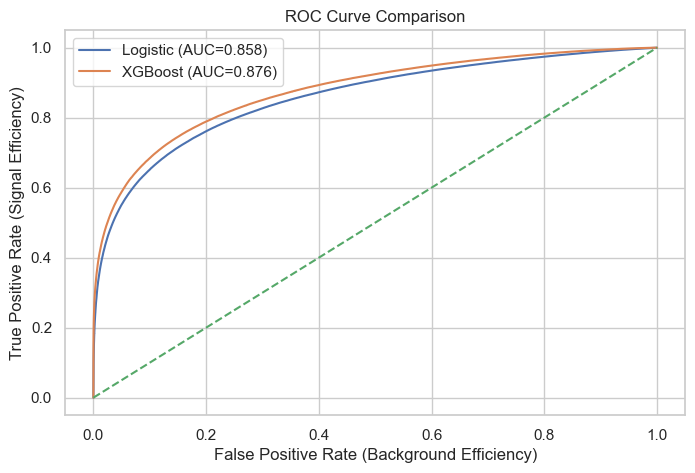

In [30]:
# ROC Curves

fpr_log, tpr_log, _ = roc_curve(y_test, y_pred_proba_log)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure()

plt.plot(fpr_log, tpr_log, label=f"Logistic (AUC={auc_log:.3f})")
plt.plot(fpr_xgb, tpr_xgb, label=f"XGBoost (AUC={auc_xgb:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")  # Random classifier line

plt.xlabel("False Positive Rate (Background Efficiency)")
plt.ylabel("True Positive Rate (Signal Efficiency)")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

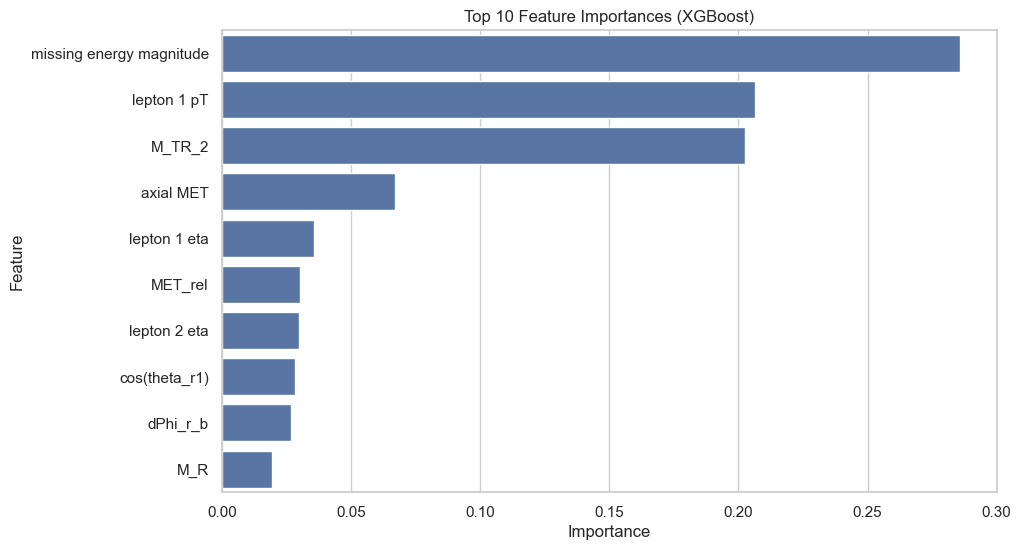

                     Feature  Importance
6   missing energy magnitude    0.285835
0                lepton 1 pT    0.206570
11                    M_TR_2    0.202498
9                  axial MET    0.066928
1               lepton 1 eta    0.035735
8                    MET_rel    0.030309
4               lepton 2 eta    0.029721
17             cos(theta_r1)    0.028319
16                  dPhi_r_b    0.026622
10                       M_R    0.019453


In [31]:
# Feature Importance in XGBoost

importances = xgb_model.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance_df.head(10)
)

plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

print(feature_importance_df.head(10))